Using device: cuda

 PART 1: DCGAN (Deep Convolutional GAN)
Loading CIFAR-10 ...
Dataset: 50000 images | Batches: 391
Generator:     3,576,704 params
Discriminator: 2,765,568 params

Training DCGAN for 5 epochs ...
  Epoch [1/5] | Loss_D: 0.3394 | Loss_G: 4.4611
  Epoch [2/5] | Loss_D: 0.4648 | Loss_G: 3.6694
  Epoch [3/5] | Loss_D: 0.7231 | Loss_G: 5.6904
  Epoch [4/5] | Loss_D: 1.2072 | Loss_G: 5.9361
  Epoch [5/5] | Loss_D: 0.4529 | Loss_G: 3.0134
DCGAN training complete.


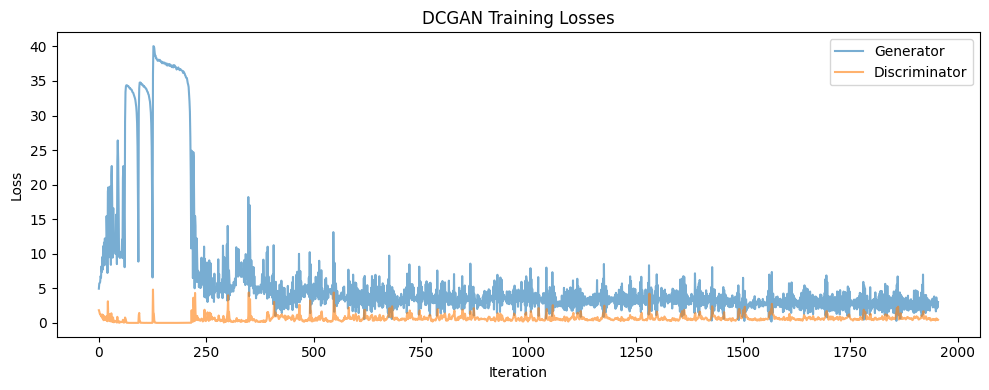


 PART 2: Latent Space Exploration
Generating 10 artistic samples ...


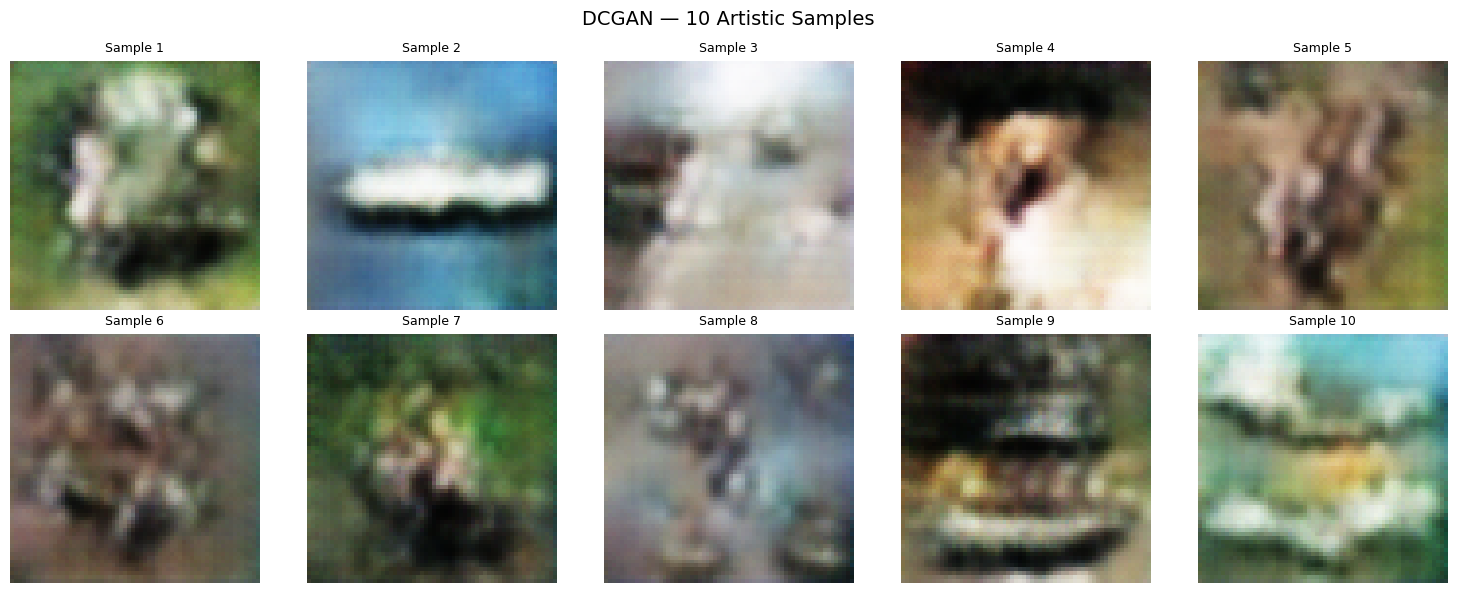

Saved → dcgan_samples.png

Interpolating between two latent vectors ...


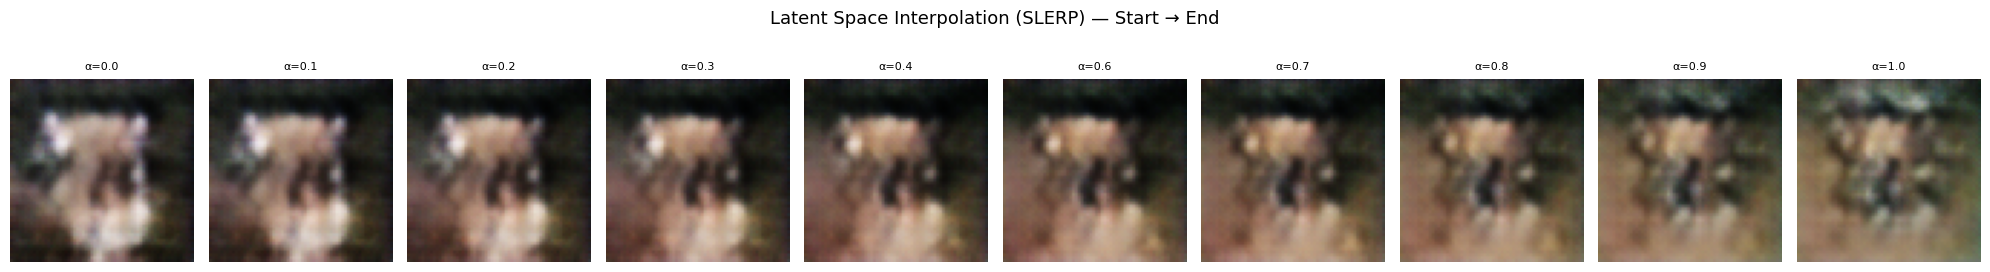

Saved → dcgan_interpolation.png

 PART 3: Advanced GAN — BigGAN (Pretrained)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Loading pretrained BigGAN-128 ...
BigGAN loaded.

Generating BigGAN samples (truncation=0.4) ...


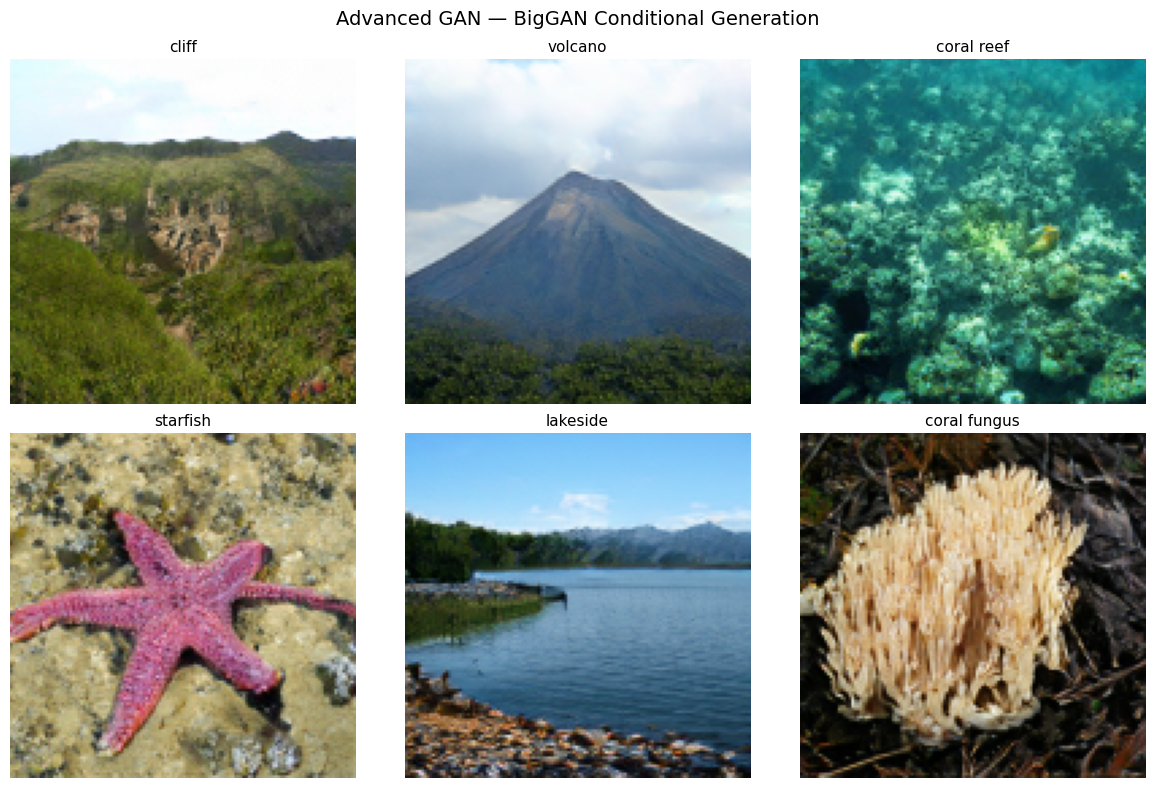

Saved → biggan_samples.png

BigGAN latent interpolation ...


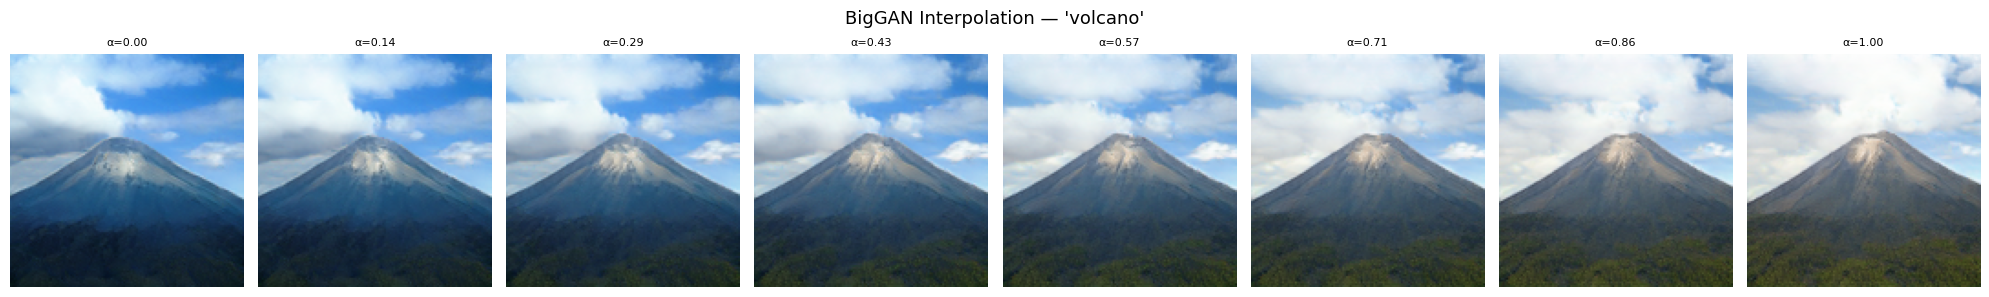

Saved → biggan_interpolation.png

 ALL DONE — Files saved:
  dcgan_samples.png        — 10 DCGAN artistic samples
  dcgan_interpolation.png  — DCGAN latent interpolation
  biggan_samples.png       — BigGAN conditional samples
  biggan_interpolation.png — BigGAN latent interpolation


In [2]:
# ============================================================
#  CSET419 – Lab 8: Artistic Outputs using GANs
#  Single cell – Colab ready
# ============================================================

# ---------- 0. Imports & Setup ----------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.datasets as dsets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import subprocess

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
#  PART 1 — DCGAN (Basic GAN)
# ============================================================
print("\n" + "="*55)
print(" PART 1: DCGAN (Deep Convolutional GAN)")
print("="*55)

# ---------- 1. Hyperparameters ----------
LATENT_DIM  = 100
IMAGE_SIZE  = 64
CHANNELS    = 3
BATCH_SIZE  = 128
EPOCHS      = 5        # ✅ was 20 — fast enough, still shows learning
LR          = 0.0002
BETA1       = 0.5

# ---------- 2. Data Preparation ----------
print("Loading CIFAR-10 ...")
transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)   # normalize to [-1, 1]
])

dataset    = dsets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Dataset: {len(dataset)} images | Batches: {len(dataloader)}")

# ---------- 3. Weight Initialization ----------
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ---------- 4. DCGAN Generator ----------
class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

# ---------- 5. DCGAN Discriminator ----------
class DCGANDiscriminator(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1)

# ---------- 6. Initialize ----------
G = DCGANGenerator(LATENT_DIM, CHANNELS).to(device)
D = DCGANDiscriminator(CHANNELS).to(device)
G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()
optim_G   = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optim_D   = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

print(f"Generator:     {sum(p.numel() for p in G.parameters()):,} params")
print(f"Discriminator: {sum(p.numel() for p in D.parameters()):,} params")

# ---------- 7. Training ----------
print(f"\nTraining DCGAN for {EPOCHS} epochs ...")
G_losses, D_losses = [], []

for epoch in range(EPOCHS):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs    = real_imgs.to(device)
        b            = real_imgs.size(0)
        real_labels  = torch.ones(b, device=device)
        fake_labels  = torch.zeros(b, device=device)

        # Train Discriminator
        optim_D.zero_grad()
        loss_real = criterion(D(real_imgs), real_labels)
        noise     = torch.randn(b, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        loss_fake = criterion(D(fake_imgs.detach()), fake_labels)
        loss_D    = loss_real + loss_fake
        loss_D.backward(); optim_D.step()

        # Train Generator
        optim_G.zero_grad()
        loss_G = criterion(D(fake_imgs), real_labels)
        loss_G.backward(); optim_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"  Epoch [{epoch+1}/{EPOCHS}] | Loss_D: {loss_D.item():.4f} | Loss_G: {loss_G.item():.4f}")

print("DCGAN training complete.")

# ---------- 8. Loss Plot ----------
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="Generator",     alpha=0.6)
plt.plot(D_losses, label="Discriminator", alpha=0.6)
plt.xlabel("Iteration"); plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend(); plt.tight_layout(); plt.show()

# ============================================================
#  PART 2 — Latent Space Exploration
# ============================================================
print("\n" + "="*55)
print(" PART 2: Latent Space Exploration")
print("="*55)

G.eval()

# ---------- 9. Generate 10 Artistic Samples ----------
print("Generating 10 artistic samples ...")
with torch.no_grad():
    samples = G(torch.randn(10, LATENT_DIM, 1, 1, device=device)).cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("DCGAN — 10 Artistic Samples", fontsize=14)
for i, ax in enumerate(axes.flat):
    img = (samples[i].permute(1,2,0).clamp(-1,1) + 1) / 2
    ax.imshow(img); ax.set_title(f"Sample {i+1}", fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig("dcgan_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → dcgan_samples.png")

# ---------- 10. Latent Interpolation (SLERP) ----------
print("\nInterpolating between two latent vectors ...")

def slerp(val, z1, z2):
    z1_n  = z1 / z1.norm(dim=1, keepdim=True)
    z2_n  = z2 / z2.norm(dim=1, keepdim=True)
    omega = torch.acos((z1_n * z2_n).sum(dim=1).clamp(-1, 1))
    so    = torch.sin(omega)
    if so.abs().item() < 1e-6:
        return (1 - val) * z1 + val * z2
    return (torch.sin((1-val)*omega)/so).view(-1,1,1,1)*z1 + \
           (torch.sin(val*omega)/so).view(-1,1,1,1)*z2

z1     = torch.randn(1, LATENT_DIM, 1, 1, device=device)
z2     = torch.randn(1, LATENT_DIM, 1, 1, device=device)
alphas = torch.linspace(0, 1, 10)

interp_imgs = []
with torch.no_grad():
    for a in alphas:
        interp_imgs.append(G(slerp(a.item(), z1, z2)).cpu().squeeze(0))

fig, axes = plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle("Latent Space Interpolation (SLERP) — Start → End", fontsize=13)
for i, ax in enumerate(axes):
    img = (interp_imgs[i].permute(1,2,0).clamp(-1,1) + 1) / 2
    ax.imshow(img); ax.set_title(f"α={alphas[i]:.1f}", fontsize=8); ax.axis("off")
plt.tight_layout()
plt.savefig("dcgan_interpolation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → dcgan_interpolation.png")

# ============================================================
#  PART 3 — BigGAN (Advanced GAN, Pretrained)
# ============================================================
print("\n" + "="*55)
print(" PART 3: Advanced GAN — BigGAN (Pretrained)")
print("="*55)

# ✅ Fix: download wordnet before importing BigGAN
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')   # needed in newer NLTK versions

subprocess.run(["pip", "install", "pytorch-pretrained-biggan", "-q"], check=True)
from pytorch_pretrained_biggan import BigGAN, one_hot_from_names, truncated_noise_sample

print("Loading pretrained BigGAN-128 ...")
biggan = BigGAN.from_pretrained('biggan-deep-128').to(device)
biggan.eval()
print("BigGAN loaded.")

# ---------- BigGAN Samples ----------
TRUNCATION = 0.4
classes    = ['cliff', 'volcano', 'coral reef', 'starfish', 'lakeside', 'coral fungus']

print(f"\nGenerating BigGAN samples (truncation={TRUNCATION}) ...")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Advanced GAN — BigGAN Conditional Generation", fontsize=14)

with torch.no_grad():
    for ax, cls in zip(axes.flat, classes):
        noise   = torch.from_numpy(truncated_noise_sample(truncation=TRUNCATION, batch_size=1)).to(device)
        cls_vec = torch.from_numpy(one_hot_from_names([cls], batch_size=1)).to(device)
        img     = biggan(noise, cls_vec, TRUNCATION)
        img     = (img.squeeze(0).cpu().permute(1,2,0).clamp(-1,1) + 1) / 2
        ax.imshow(img); ax.set_title(cls, fontsize=11); ax.axis("off")

plt.tight_layout()
plt.savefig("biggan_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → biggan_samples.png")

# ---------- BigGAN Interpolation ----------
print("\nBigGAN latent interpolation ...")
target_cls = "volcano"
cls_vec    = torch.from_numpy(one_hot_from_names([target_cls], batch_size=1)).to(device)
z1 = torch.from_numpy(truncated_noise_sample(truncation=TRUNCATION, batch_size=1)).to(device)
z2 = torch.from_numpy(truncated_noise_sample(truncation=TRUNCATION, batch_size=1)).to(device)

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle(f"BigGAN Interpolation — '{target_cls}'", fontsize=13)
with torch.no_grad():
    for i, a in enumerate(torch.linspace(0, 1, 8)):
        z   = (1 - a) * z1 + a * z2
        img = biggan(z, cls_vec, TRUNCATION)
        img = (img.squeeze(0).cpu().permute(1,2,0).clamp(-1,1) + 1) / 2
        axes[i].imshow(img); axes[i].set_title(f"α={a:.2f}", fontsize=8); axes[i].axis("off")

plt.tight_layout()
plt.savefig("biggan_interpolation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → biggan_interpolation.png")

# ============================================================
print("\n" + "="*55)
print(" ALL DONE — Files saved:")
print("  dcgan_samples.png        — 10 DCGAN artistic samples")
print("  dcgan_interpolation.png  — DCGAN latent interpolation")
print("  biggan_samples.png       — BigGAN conditional samples")
print("  biggan_interpolation.png — BigGAN latent interpolation")
print("="*55)